# SIMILIS baseline: dataset structure and EDA

Проверка структуры датасета, связка `metadata ↔ image`, и базовый визуальный/табличный EDA корпуса

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
from IPython.display import display

warnings.filterwarnings('ignore', category=UserWarning)
ImageFile.LOAD_TRUNCATED_IMAGES = True
Image.MAX_IMAGE_PIXELS = None

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = True

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'cu_data' / 'cu_data'
CSV_PATH = DATA_ROOT / 'selected_by_name_iimk_subset_public.csv'
IMAGE_ROOT = DATA_ROOT / 'dataset'
MANIFEST_PATH = PROJECT_ROOT / 'data' / 'interim' / 'manifest_raw.csv'
IMAGE_STATS_PATH = PROJECT_ROOT / 'data' / 'interim' / 'image_stats_basic.csv'
HEURISTICS_PATH = PROJECT_ROOT / 'data' / 'interim' / 'image_visual_heuristics_sample50.csv'

print('CSV_PATH:', CSV_PATH)
print('IMAGE_ROOT:', IMAGE_ROOT)
print('MANIFEST_PATH exists:', MANIFEST_PATH.exists())
print('IMAGE_STATS_PATH exists:', IMAGE_STATS_PATH.exists())
print('HEURISTICS_PATH exists:', HEURISTICS_PATH.exists())

CSV_PATH: /Users/artemvardanan/Downloads/DL_project1/data/raw/cu_data/cu_data/selected_by_name_iimk_subset_public.csv
IMAGE_ROOT: /Users/artemvardanan/Downloads/DL_project1/data/raw/cu_data/cu_data/dataset
MANIFEST_PATH exists: True
IMAGE_STATS_PATH exists: True
HEURISTICS_PATH exists: True


## Task 3. Structure and metadata-image linkage

In [3]:
df = pd.read_csv(CSV_PATH)
print('CSV rows:', len(df))
print('Columns:')
print(df.columns.tolist())
display(df.head())

CSV rows: 1389
Columns:
['Unnamed: 0', 'code', 'name', 'description', 'material', 'size', 'fragm', 'cultlayer', 'execorg', 'survyear']


,Unnamed: 0,code,name,description,material,size,fragm,cultlayer,execorg,survyear
0,40,М102-2012-1-0494,Изразец,Изразца красноглиняного с белой поливой и коба...,Керамика,"7+ х 3,5+ х 1,1+ см",Фрагмент,Пестрая мешаная супесь,ИИМК РАН,2012.0
1,41,М102-2012-1-0496,Изразец,Изразца красноглиняного плоского с белой полив...,Керамика,"9,9+ х 6,4+ х 1,3+ см",Фрагмент,Пестрая мешаная супесь,ИИМК РАН,2012.0
2,49,М102-2012-1-0529,Изразец,Изразца-перемычки красноглиняного с белой поли...,Керамика,"4,5+ х 4,3 х 4,2+ см",Фрагмент,Пестрая мешаная супесь,ИИМК РАН,2012.0
3,59,М102-2012-1-0585,Тарелка,Сосуда (тарелки ?) фаянсового с белой поливой ...,Фаянс,D? см,Фрагмент,Дерн со щепой,ИИМК РАН,2012.0
4,63,М102-2012-1-0603,Изразец,Изразца (перемычки?) красноглиняного с белой п...,Керамика,"3,8+ х 2,8 х 5,1+ см",Фрагмент,Дерн со щепой,ИИМК РАН,2012.0


В открытом сабсете нет явной колонки `image_file`, поэтому для baseline используем следующую связку:

- `artifact_id = code`
- `group_key = code`
- `image_file = code + '_orig.jpg'`

Это правило покрывает почти весь открытый датасет и даёт воспроизводимый способ борьбы с утечкой по группам.

In [4]:
manifest = df.copy()
manifest['artifact_id'] = manifest['code'].astype(str)
manifest['group_key'] = manifest['artifact_id']
manifest['image_file'] = manifest['artifact_id'] + '_orig.jpg'
manifest['image_path'] = manifest['image_file'].map(lambda x: IMAGE_ROOT / x)
manifest['image_exists'] = manifest['image_path'].map(Path.exists)

MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
manifest.to_csv(MANIFEST_PATH, index=False)

print('Manifest saved to:', MANIFEST_PATH)
display(manifest[['code', 'artifact_id', 'group_key', 'image_file', 'image_exists']].head())

Manifest saved to: /Users/artemvardanan/Downloads/DL_project1/data/interim/manifest_raw.csv


,code,artifact_id,group_key,image_file,image_exists
0,М102-2012-1-0494,М102-2012-1-0494,М102-2012-1-0494,М102-2012-1-0494_orig.jpg,True
1,М102-2012-1-0496,М102-2012-1-0496,М102-2012-1-0496,М102-2012-1-0496_orig.jpg,True
2,М102-2012-1-0529,М102-2012-1-0529,М102-2012-1-0529,М102-2012-1-0529_orig.jpg,True
3,М102-2012-1-0585,М102-2012-1-0585,М102-2012-1-0585,М102-2012-1-0585_orig.jpg,True
4,М102-2012-1-0603,М102-2012-1-0603,М102-2012-1-0603,М102-2012-1-0603_orig.jpg,True


In [5]:
total_rows = len(manifest)
valid_rows = int(manifest['image_exists'].sum())
broken_rows = int((~manifest['image_exists']).sum())
dup_image_files = int(manifest['image_file'].duplicated().sum())
dup_artifact_ids = int(manifest['artifact_id'].duplicated().sum())
dup_group_keys = int(manifest['group_key'].duplicated().sum())

print('Rows total:', total_rows)
print('Rows with valid image path:', valid_rows)
print('Broken image paths:', broken_rows)
print('Duplicated image_file:', dup_image_files)
print('Repeated artifact_id:', dup_artifact_ids)
print('Repeated group_key:', dup_group_keys)

Rows total: 1389
Rows with valid image path: 1387
Broken image paths: 2
Duplicated image_file: 1
Repeated artifact_id: 1
Repeated group_key: 1


In [6]:
print('Rows with broken paths:')
display(manifest.loc[~manifest['image_exists'], ['code', 'name', 'description', 'image_file']])

print('Repeated artifact_id/group_key rows:')
display(manifest.loc[manifest['artifact_id'].duplicated(keep=False), ['code', 'name', 'description', 'image_file']])

Rows with broken paths:


,code,name,description,image_file
502,46858,Игрушка,NaN,46858_orig.jpg
503,46858,Игрушка,NaN,46858_orig.jpg


Repeated artifact_id/group_key rows:


,code,name,description,image_file
502,46858,Игрушка,NaN,46858_orig.jpg
503,46858,Игрушка,NaN,46858_orig.jpg


In [7]:
valid_manifest = manifest[manifest['image_exists']].copy()
print('Image files on disk:', len(list(IMAGE_ROOT.glob('*.jpg'))))
print('Valid rows kept for baseline:', len(valid_manifest))

Image files on disk: 1388
Valid rows kept for baseline: 1387


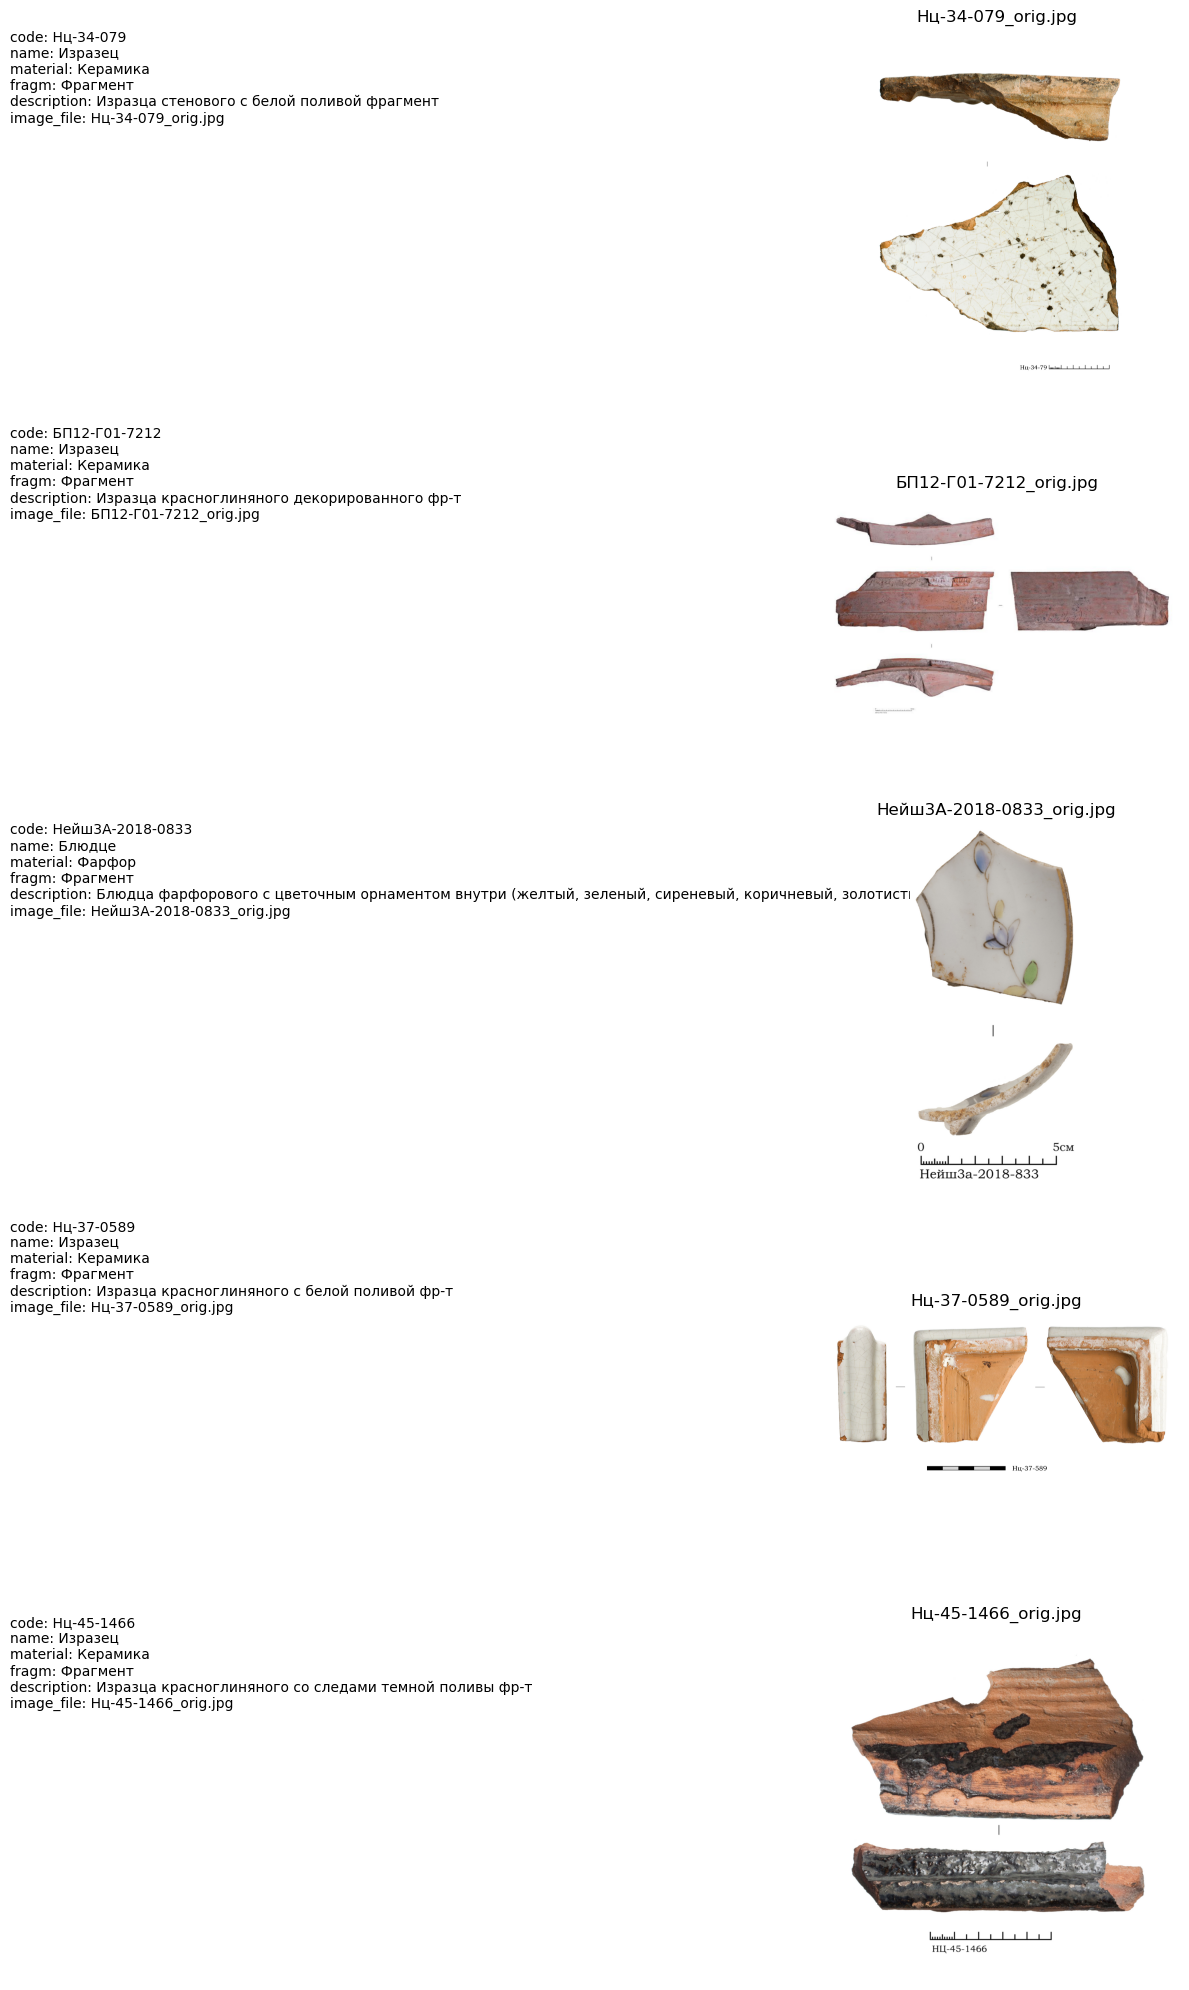

In [8]:
example_rows = valid_manifest.sample(5, random_state=42).reset_index(drop=True)
fig, axes = plt.subplots(len(example_rows), 2, figsize=(12, 4 * len(example_rows)))

for i, row in example_rows.iterrows():
    row_dict = row[['code', 'name', 'material', 'fragm', 'description', 'image_file']].to_dict()
    axes[i, 0].axis('off')
    axes[i, 0].text(0, 1, '\n'.join([f'{k}: {v}' for k, v in row_dict.items()]), va='top', fontsize=10)

    with Image.open(row['image_path']) as img:
        axes[i, 1].imshow(img)
    axes[i, 1].set_title(row['image_file'])
    axes[i, 1].axis('off')

plt.tight_layout()

## Task 4. Visual and tabular EDA

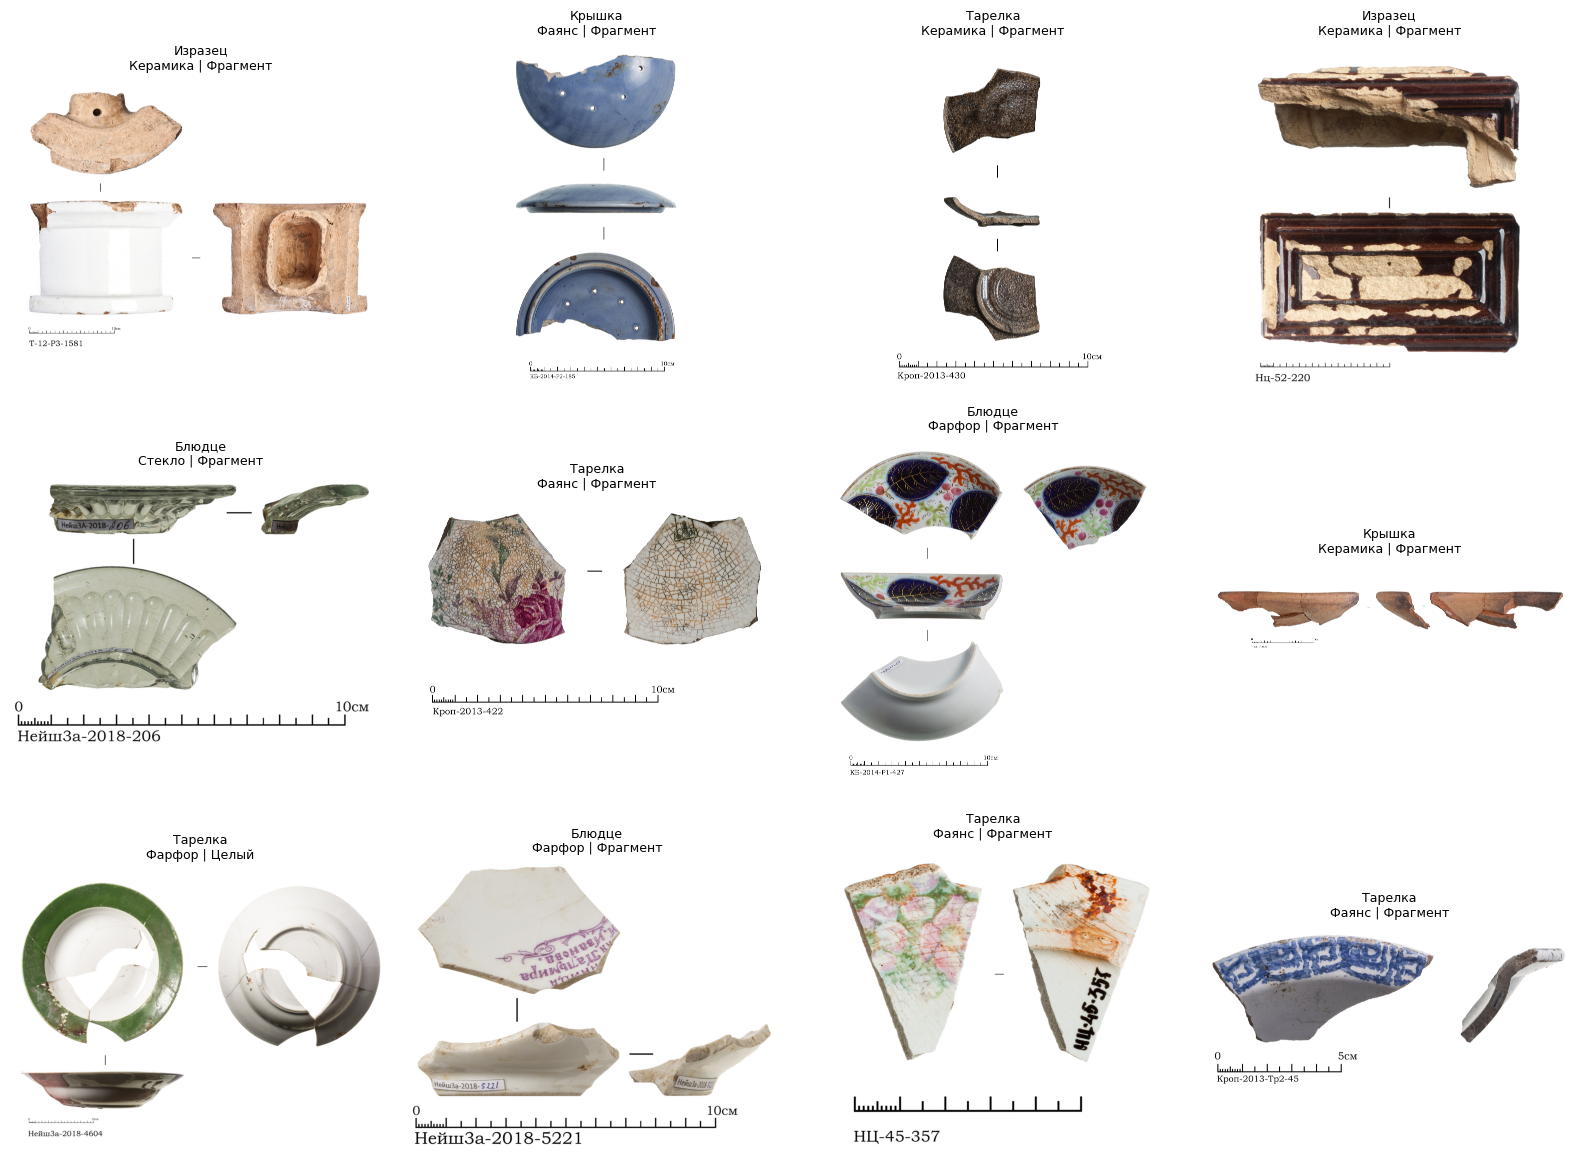

In [9]:
sample_grid = valid_manifest.sample(12, random_state=7).reset_index(drop=True)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_grid.iterrows()):
    with Image.open(row['image_path']) as img:
        ax.imshow(img)
    ax.set_title(f"{row['name']}\n{row['material']} | {row['fragm']}", fontsize=9)
    ax.axis('off')

plt.tight_layout()

In [10]:
if IMAGE_STATS_PATH.exists():
    image_stats = pd.read_csv(IMAGE_STATS_PATH)
else:
    rows = []
    for _, row in valid_manifest.iterrows():
        with Image.open(row['image_path']) as img:
            w, h = img.size
        rows.append({
            'image_file': row['image_file'],
            'artifact_id': row['artifact_id'],
            'width': w,
            'height': h,
            'aspect_ratio': w / h,
            'pixels': w * h,
        })
    image_stats = pd.DataFrame(rows)
    image_stats.to_csv(IMAGE_STATS_PATH, index=False)

display(image_stats.describe())

,width,height,aspect_ratio,pixels
count,1387.000000,1387.000000,1387.000000,1.387000e+03
mean,5202.269647,4281.936554,1.405938,2.506832e+07
std,2937.059868,2455.619446,0.764998,2.231419e+07
min,543.000000,218.000000,0.258162,2.354400e+05
25%,3168.000000,2555.000000,0.768383,9.445849e+06
50%,4674.000000,3655.000000,1.315858,1.980721e+07
75%,6916.000000,5502.500000,1.899927,3.494383e+07
max,18808.000000,14212.000000,4.954128,1.839987e+08


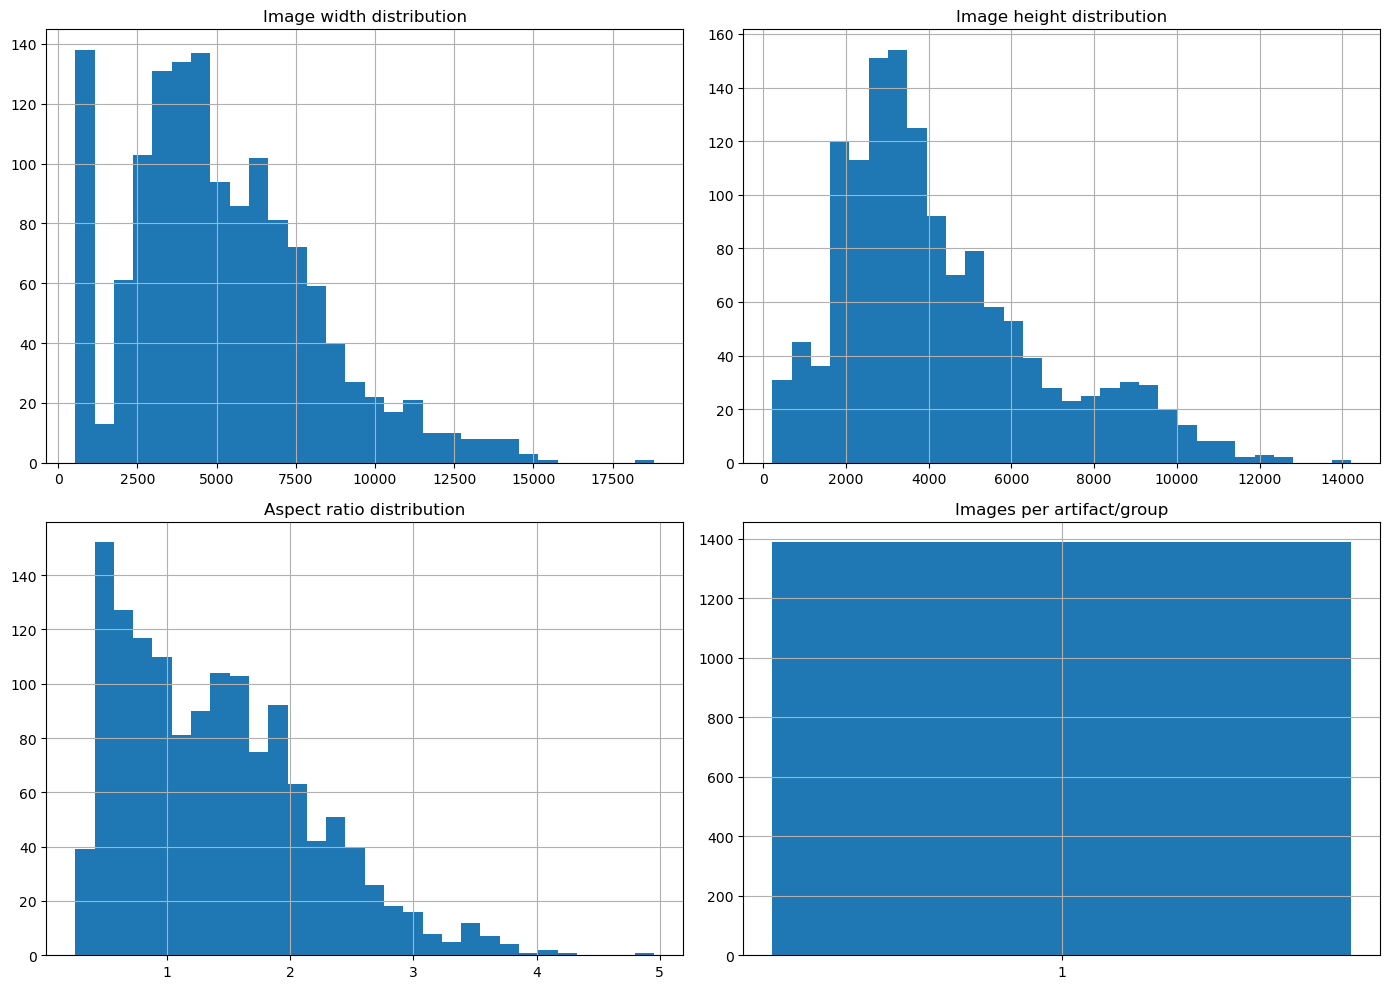

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(image_stats['width'], bins=30)
axes[0, 0].set_title('Image width distribution')

axes[0, 1].hist(image_stats['height'], bins=30)
axes[0, 1].set_title('Image height distribution')

axes[1, 0].hist(image_stats['aspect_ratio'], bins=30)
axes[1, 0].set_title('Aspect ratio distribution')

group_sizes = valid_manifest.groupby('group_key').size()
axes[1, 1].hist(group_sizes, bins=np.arange(1, group_sizes.max() + 2) - 0.5, rwidth=0.9)
axes[1, 1].set_title('Images per artifact/group')
axes[1, 1].set_xticks(sorted(group_sizes.unique())[:10])

plt.tight_layout()

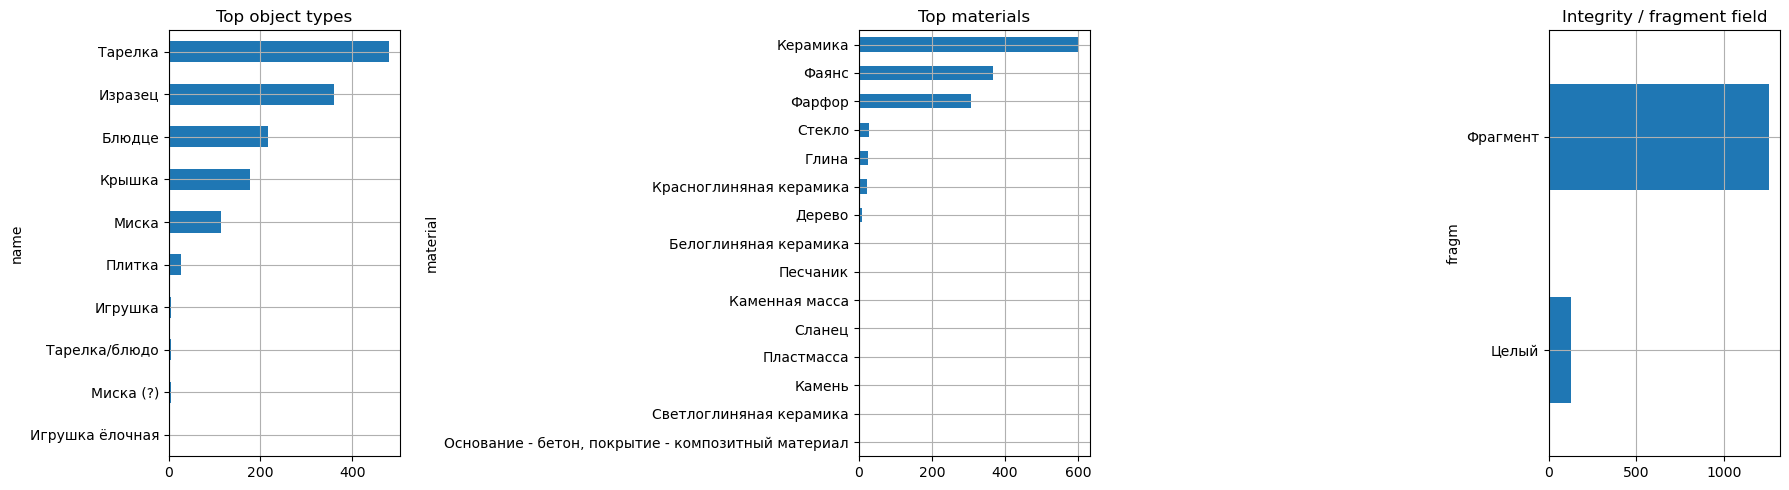

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

valid_manifest['name'].value_counts().head(15).sort_values().plot(kind='barh', ax=axes[0], title='Top object types')
valid_manifest['material'].fillna('MISSING').value_counts().head(15).sort_values().plot(kind='barh', ax=axes[1], title='Top materials')
valid_manifest['fragm'].fillna('MISSING').value_counts().sort_values().plot(kind='barh', ax=axes[2], title='Integrity / fragment field')

plt.tight_layout()

In [13]:
problem_candidates = pd.concat([
    image_stats.nsmallest(3, 'pixels'),
    image_stats.nlargest(3, 'pixels'),
    image_stats.nsmallest(2, 'aspect_ratio'),
    image_stats.nlargest(2, 'aspect_ratio'),
]).drop_duplicates('image_file')

problem_rows = valid_manifest.merge(problem_candidates[['image_file', 'width', 'height', 'aspect_ratio', 'pixels']], on='image_file')
display(problem_rows[['image_file', 'name', 'material', 'fragm', 'width', 'height', 'aspect_ratio', 'pixels']])

,image_file,name,material,fragm,width,height,aspect_ratio,pixels
0,Кроп-2013-203_orig.jpg,Миска,Керамика,Фрагмент,15292,3547,4.311249,54240724
1,Кроп-2013-267_orig.jpg,Тарелка,Фарфор,Фрагмент,3669,14212,0.258162,52143828
2,БП12-Г01-2475_orig.jpg,Блюдце,Фарфор,Фрагмент,1080,319,3.385580,344520
3,БП12-Г01-5772_orig.jpg,Крышка,Серолощеная керамика,Фрагмент,1080,393,2.748092,424440
4,БП12-Г02-5226_orig.jpg,Тарелка,Фаянс,Фрагмент,1080,218,4.954128,235440
5,БП12-Г02-5243_orig.jpg,Блюдце,Фаянс,Фрагмент,543,1920,0.282813,1042560
6,ВО-1л58-2017-0014_orig.jpg,Изразец,Керамика,Фрагмент,18808,9783,1.922519,183998664
7,ВО-1л58-2017-0527_orig.jpg,Изразец,Керамика,Фрагмент,13749,9756,1.409287,134135244
8,ВО-1л58-2017-0780_orig.jpg,Изразец,Керамика,Фрагмент,12000,11032,1.087745,132384000


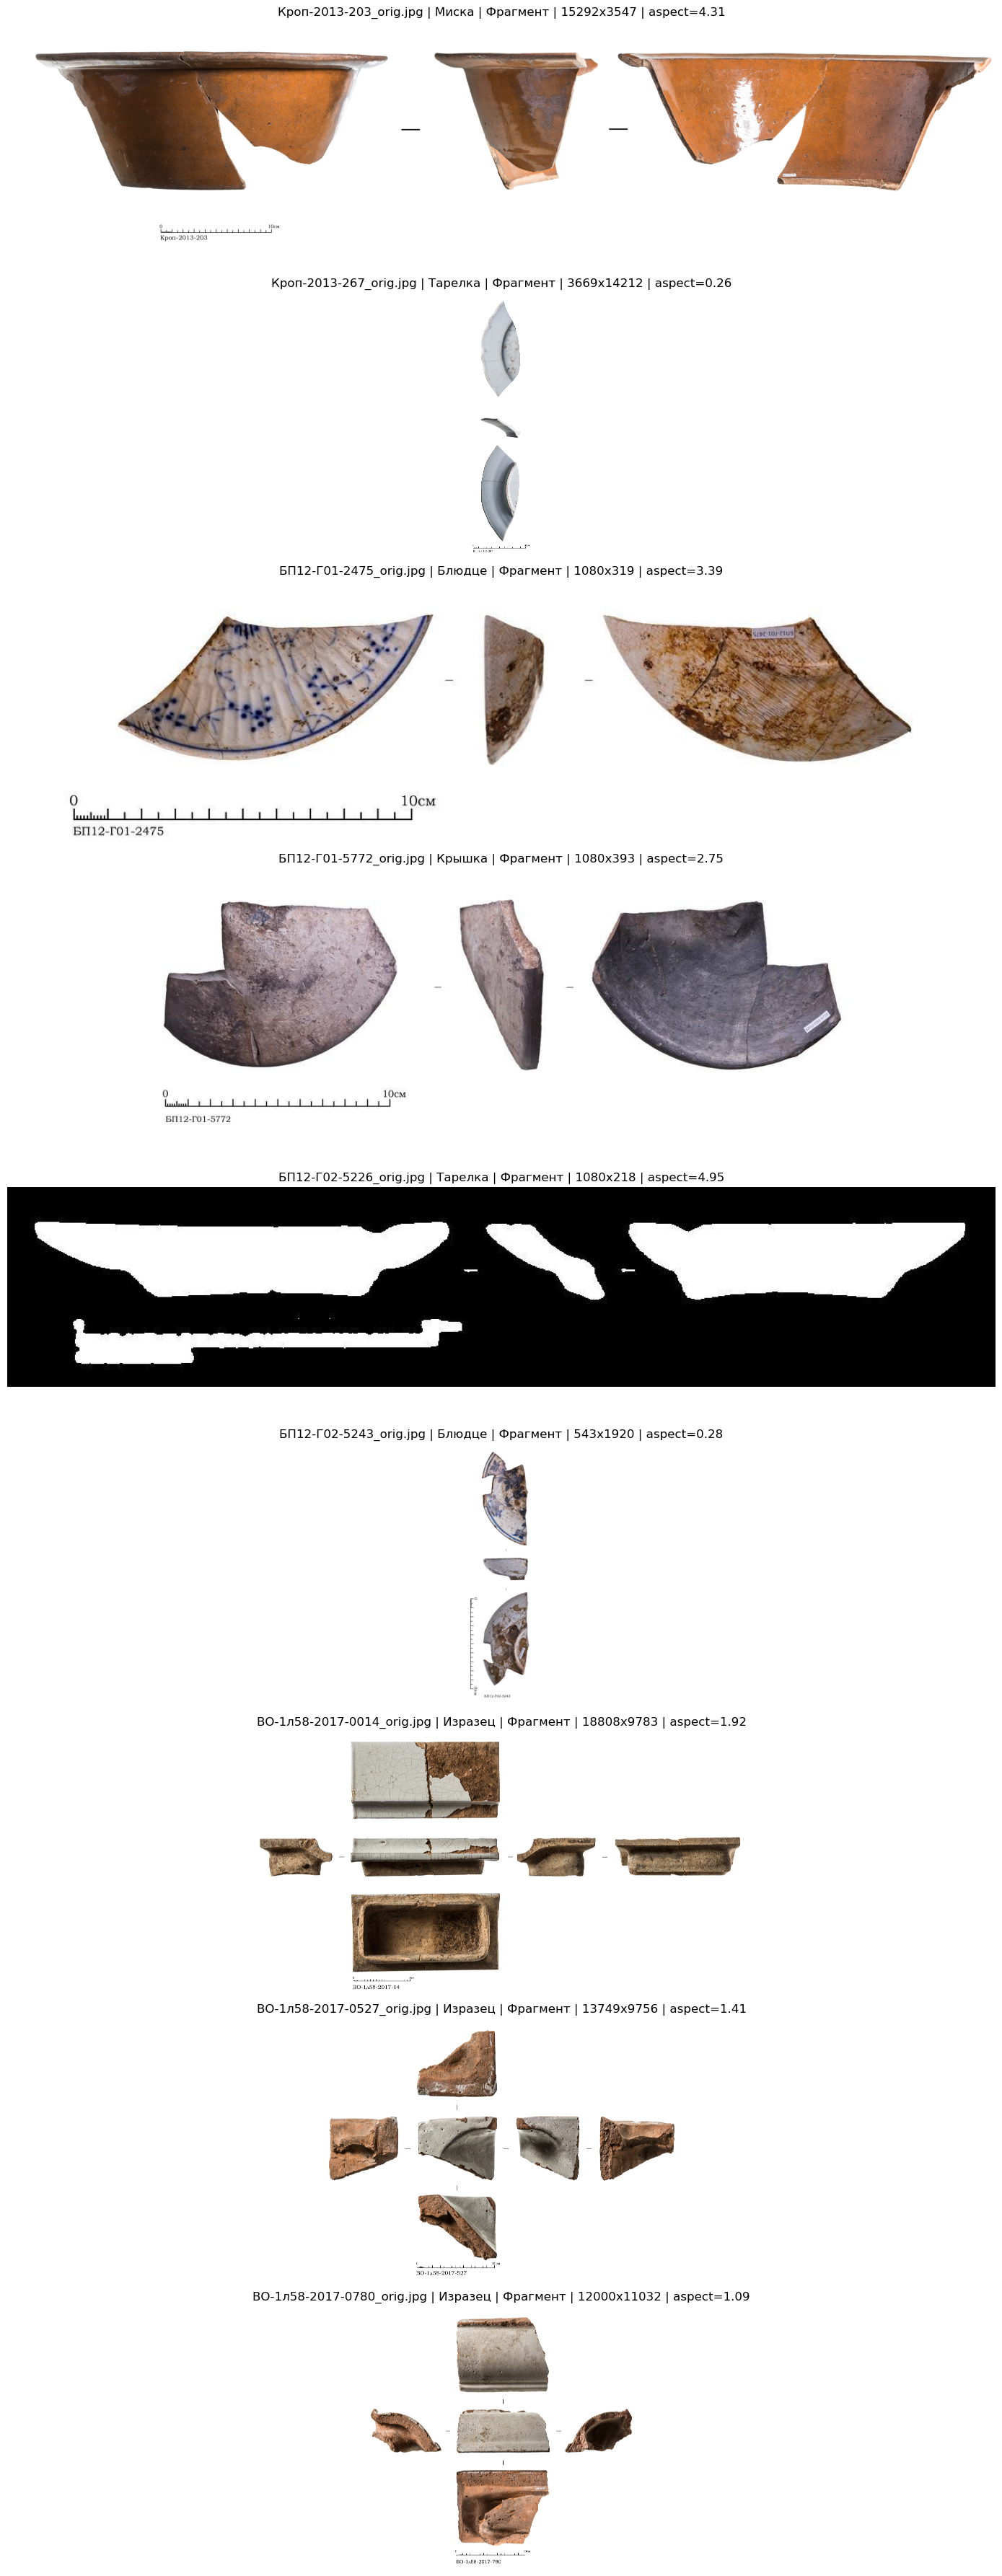

In [14]:
problem_rows = problem_rows.reset_index(drop=True)
n = min(len(problem_rows), 10)
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n))
if n == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, problem_rows.head(n).iterrows()):
    with Image.open(row['image_path']) as img:
        ax.imshow(img)
    ax.set_title(
        f"{row['image_file']} | {row['name']} | {row['fragm']} | "
        f"{row['width']}x{row['height']} | aspect={row['aspect_ratio']:.2f}"
    )
    ax.axis('off')

plt.tight_layout()

In [15]:
if HEURISTICS_PATH.exists():
    heuristics = pd.read_csv(HEURISTICS_PATH)
else:
    sample = valid_manifest.sample(n=min(50, len(valid_manifest)), random_state=42).copy()
    rows = []
    for _, row in sample.iterrows():
        with Image.open(row['image_path']) as img:
            img = img.convert('RGB')
            img.thumbnail((512, 512))
            arr = np.array(img)

        gray = arr.mean(axis=2)
        border = np.concatenate([gray[0], gray[-1], gray[:, 0], gray[:, -1]])
        border_mean = border.mean()
        if border_mean > 245:
            bg_type = 'white'
        elif border_mean > 220:
            bg_type = 'light-gray'
        else:
            bg_type = 'other'

        fg_mask = gray < (border_mean - 15)
        foreground_ratio = float(fg_mask.mean())
        cols = fg_mask.mean(axis=0)
        rows_fg = fg_mask.mean(axis=1)

        has_scale_bar = bool(((rows_fg[-20:] > 0.35).any() or (cols[:20] > 0.35).any() or (cols[-20:] > 0.35).any()) and foreground_ratio < 0.45)
        has_overlay_text = bool((rows_fg[:30] > 0.10).any() or (rows_fg[-30:] > 0.10).any())

        if foreground_ratio < 0.12:
            layout_mode = 'close-up_or_small-object'
        elif fg_mask.mean(axis=0).max() < 0.35 and fg_mask.mean(axis=1).max() < 0.35:
            layout_mode = 'multi-view_or_sparse'
        else:
            layout_mode = 'single-fragment'

        rows.append({
            'image_file': row['image_file'],
            'artifact_id': row['artifact_id'],
            'foreground_ratio': foreground_ratio,
            'bg_type': bg_type,
            'has_scale_bar': has_scale_bar,
            'has_overlay_text': has_overlay_text,
            'layout_mode': layout_mode,
        })

    heuristics = pd.DataFrame(rows)
    heuristics.to_csv(HEURISTICS_PATH, index=False)

display(heuristics.head(10))

,image_file,artifact_id,foreground_ratio,bg_type,has_scale_bar,has_overlay_text,layout_mode
0,Нц-34-079_orig.jpg,Нц-34-079,0.2814,white,False,False,single-fragment
1,БП12-Г01-7212_orig.jpg,БП12-Г01-7212,0.2782,white,False,False,single-fragment
2,Нейш3А-2018-0833_orig.jpg,Нейш3А-2018-0833,0.3904,white,True,True,single-fragment
3,Нц-37-0589_orig.jpg,Нц-37-0589,0.4074,white,False,True,single-fragment
4,Нц-45-1466_orig.jpg,Нц-45-1466,0.4087,white,False,False,single-fragment
5,БП12-Г02-4190_orig.jpg,БП12-Г02-4190,0.3117,white,True,True,single-fragment
6,Нц-48-376_orig.jpg,Нц-48-376,0.2005,white,False,False,single-fragment
7,Нц-23-2188_orig.jpg,Нц-23-2188,0.2926,white,False,True,single-fragment
8,Нц-45-0018_orig.jpg,Нц-45-0018,0.2859,white,False,True,single-fragment
9,Нц-45-0558_orig.jpg,Нц-45-0558,0.3209,white,False,True,single-fragment


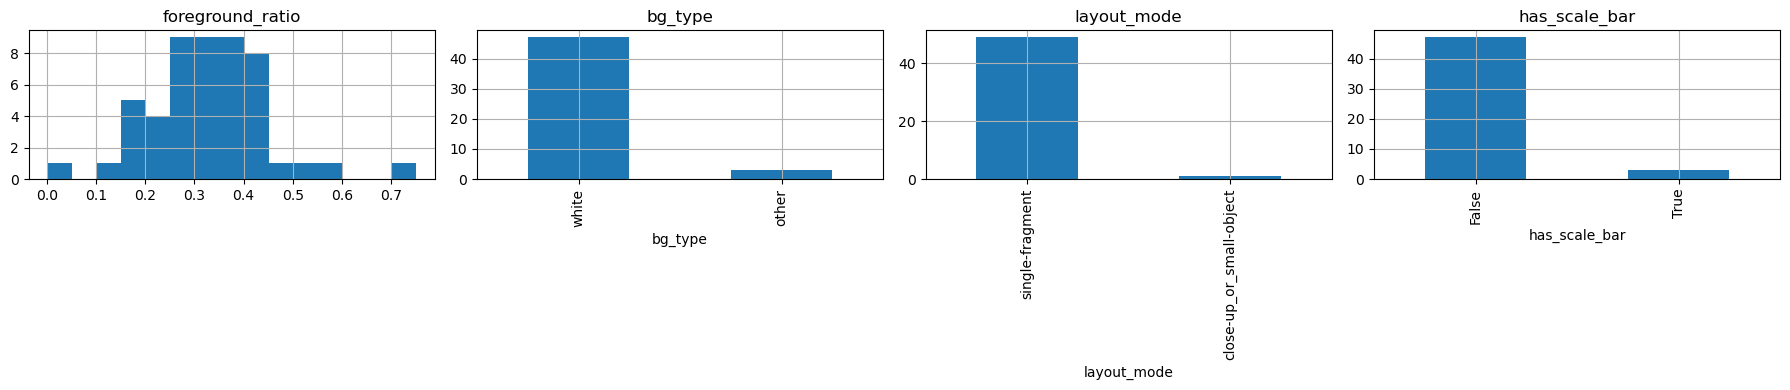

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].hist(heuristics['foreground_ratio'], bins=15)
axes[0].set_title('foreground_ratio')

heuristics['bg_type'].value_counts().plot(kind='bar', ax=axes[1], title='bg_type')
heuristics['layout_mode'].value_counts().plot(kind='bar', ax=axes[2], title='layout_mode')
heuristics['has_scale_bar'].value_counts().plot(kind='bar', ax=axes[3], title='has_scale_bar')

plt.tight_layout()

## Short EDA conclusion

- В корпусе очень разные размеры изображений: от маленьких вытянутых фрагментов до очень больших карточек.
- Есть экстремальные aspect ratio, поэтому `resize` без сохранения пропорций и агрессивный `crop` небезопасны.
- Фон чаще всего белый, а значит модель может начать использовать макет карточки, подписи и линейки как shortcut.
- Встречаются очень крупные и очень вытянутые кадры, которые требуют аккуратного preprocessing (`longest-side resize + pad`).
- Для baseline важно держать `group_key` на уровне `code`, чтобы не разнести одинаковые/связанные изображения между split'ами.